This Notebook provides an example of the MaskedDiffusionLanguageModel's ability to model some elementary data.

In [1]:
using Diffusions, Random, StatsBase, Flux, OneHotArrays, Distributions, Plots, Random, StatsPlots, LaTeXStrings
using Flux
using NNlib
using Random
using LinearAlgebra
include("diffusion.jl")
include("loss.jl")
include("Diffusions.jl/src/maskedarrays.jl")
rng = Random.default_rng()

TaskLocalRNG()

# Helper Functions

In [2]:
# This function runs into errors due to the Process type defined in Diffusions.jl
# Therefore, it is called here once again to resolve this error
# This problem will disappear when the MaskedDiffusionLanguageModels are integrated into the package

import Diffusions: sampleforward

function sampleforward(rng::AbstractRNG, process::Process, t::Real, x::AbstractArray)
    x = copy(x)
    maskedvec(x) .= _sampleforward(rng, process, t, maskedvec(x))
    return x
end

function sampleforward(rng::AbstractRNG, process::Process, t::AbstractVector{<:Real}, x::AbstractArray)
    x = copy(x)
    for i in axes(x, ndims(x))
        maskedvec(x, i) .= _sampleforward(rng, process, t[i], maskedvec(x, i))
    end
    return x
end


sampleforward (generic function with 6 methods)

In [3]:
import Diffusions: eq_dist
eq_dist(model::MaskedDiffusionLanguageModel) = Categorical(model.vocab_size)

eq_dist (generic function with 5 methods)

In [4]:
# These functions run into the same problems as the ones mentioned above

import Diffusions: samplebackward

function checktimesteps(timesteps)
    length(timesteps) ≥ 2 || throw(ArgumentError("timesteps must have at least two timesteps"))
    issorted(timesteps) || throw(ArgumentError("timesteps must be increasing"))
    all(>(0), timesteps) || throw(ArgumentError("all timesteps must be positive"))
end

struct NullTracker end

track!(::NullTracker, t, x, x0) = nothing


struct Tracker
    time::Vector
    data::Vector
    x0::Vector
end

Tracker() = Tracker([], [], [])

function track!(tracker::Tracker, t, x, x0)
    push!(tracker.time, t)
    push!(tracker.data, x)
    push!(tracker.x0, x0)
    return nothing
end


function samplebackward(rng::AbstractRNG, guess, process, timesteps, x; tracker=NullTracker())
    checktimesteps(timesteps)
    i = lastindex(timesteps)
    t = timesteps[i]
    while i > firstindex(timesteps)
        s = timesteps[i-1]
        x_0 = guess(x, t)
        x = endpoint_conditioned_sample(rng, process, s, t, x_0, x)
        # @show x
        # track!(tracker, s, x, x_0)
        t = s
        i -= 1
    end
    return x
end

samplebackward (generic function with 2 methods)

In [5]:
function endpoint_conditioned_sample(rng::AbstractRNG, process::Process, s::Real, t::Real, x_0::AbstractArray, x_t::AbstractArray)
    if x_t isa MaskedArray
        # x_0 inherits masked elements from x_t
        x_0 = MaskedArray(x_0, x_t.indices)
    end
    x = copy(x_t)
    maskedvec(x) .= _endpoint_conditioned_sample(rng, process, s, t, maskedvec(x_0), maskedvec(x_t))
    return x
end

endpoint_conditioned_sample(rng::AbstractRNG, process, s::Real, t::Real, x_0, x_t) =
    endpoint_conditioned_sample.(rng, process, s, t, x_0, x_t)

# sample x at time s conditioned on x_0 at time 0 and x_t at time t
endpoint_conditioned_sample(P::Process, s::Real, t::Real, x_0, x_t) = endpoint_conditioned_sample(Random.default_rng(), P, s, t, x_0, x_t)


endpoint_conditioned_sample (generic function with 3 methods)

# The Data

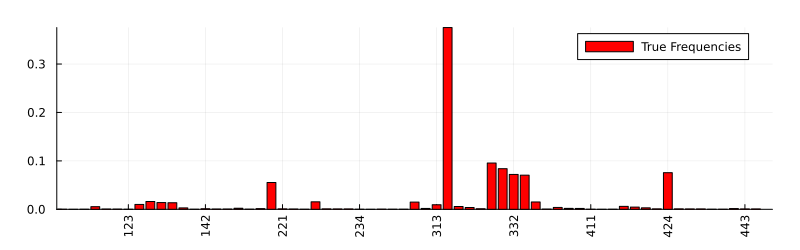

In [13]:
#Setting up a toy Markov sequence generator
S = [0.06591801058555521, 0.07969206822877058, 0.7577065839917972, 0.09668333719387696]
M1 = [0.08846562872099392 0.16990851783433247 0.7057593661240716 0.035866487320601916; 0.7431475939699389 0.21587009667771628 0.03183492266912633 0.009147386683218569; 0.5299436666548881 0.14037279287634963 0.31880667650890665 0.010876863959855763; 0.06768187476034546 0.8712803961334261 0.026959057317955764 0.03407867178827272]
M2 = [0.03711853694508748 0.004654670142378095 0.02356516471832978 0.9346616281942046; 0.05468190341435613 0.035849693778767566 0.010983526474084716 0.8984848763327916; 0.34718976966999127 0.29844003126407787 0.29174999882526814 0.06262020024066273; 0.06343354243884528 0.46980429610053 0.23584821143715762 0.23091395002346707]


#=
#If you wanted to draw the seq gen randomly
S = exp.(randn(4) .* 1.5)
S ./= sum(S)

M1 = exp.(randn(4,4) .* 1.5)
M1 ./= sum(M1 , dims = 2)

M2 = exp.(randn(4,4) .* 1.5)
M2 ./= sum(M2 , dims = 2)
=#


function target_sample(;S = S, M1 = M1, M2 = M2)
    a = rand(Categorical(S))
    b = rand(Categorical(M1[a,:]))
    c = rand(Categorical(M2[b,:]))
    return [a,b,c]
end

seq_matrix = hcat([[k,j,i] for i in 1:4, j in 1:4, k in 1:4]...)
all_seqs = [seq_matrix[:,i] for i in 1:size(seq_matrix,2)];
prob_seq(seq,S,M1,M2) = S[seq[1]]*M1[seq[1],seq[2]]*M2[seq[2],seq[3]]
all_probs = prob_seq.(all_seqs,Ref(S),Ref(M1),Ref(M2));

bar([join(string.(a)) for a in all_seqs], all_probs,
    xrotation = 90, size = (800,250), label = "True Frequencies",
    color = "red", margins = 0.5Plots.cm, xlim = (0,65))

# RoPE Implementation

## Implementation with RoPE, but not optimized

In [6]:
using Flux, Functors
using NeuralAttentionlib
using NeuralAttentionlib: multihead_qkv_attention, CausalMask, with_rotary_position_embedding

struct TimestepEmbedder
    mlp::Chain
    freqs::Vector{Float32}
end

function TimestepEmbedder(dim::Int; max_period::Float32 = 10000f0)
    half = div(dim, 2)
    freqs = exp.(-log(max_period) * Float32.(range(0, 1, length=half)) / half)
    TimestepEmbedder(
        Chain(
            Dense(dim, dim * 4, relu),
            Dense(dim * 4, dim)
        ),
        freqs
    )
end

function timestep_embedding(t::Real, freqs::Vector{Float32})
    args = t .* freqs
    embedding = vcat(sin.(args), cos.(args))
    if length(freqs) * 2 < length(embedding)
        embedding = vcat(embedding, zero(t))
    end
    return Float32.(embedding)
end

function (te::TimestepEmbedder)(t::Real)
    t_freq = timestep_embedding(t, te.freqs)
    return te.mlp(t_freq)
end

struct AdaLN
    norm::LayerNorm
    shift::Dense
    scale::Dense
end

function AdaLN(dim::Int, cond_dim::Int)
    AdaLN(
        LayerNorm(dim),
        Dense(cond_dim, dim),
        Dense(cond_dim, dim)
    )
end

function (aln::AdaLN)(x::AbstractArray, cond::AbstractVector)
    normalized = aln.norm(x)
    shift = aln.shift(cond)
    scale = aln.scale(cond)
    return normalized .* (1 .+ reshape(scale, :, 1, 1)) .+ reshape(shift, :, 1, 1)
end

struct MultiheadAttention{Q,K,V,O}
    head::Int
    future::Bool
    iqproj::Q
    ikproj::K
    ivproj::V
    oproj::O
    rope_dim::Int
end

Functors.@functor MultiheadAttention (iqproj, ikproj, ivproj, oproj)

function MultiheadAttention(head, hidden_size, head_size; future = true)
    MultiheadAttention(head, future,
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(head_size * head, hidden_size),
        head_size
    )
end

function (mha::MultiheadAttention)(q, k, v)
    qkv_attention = x -> multihead_qkv_attention(mha.head,
        mha.iqproj(x[1]), mha.ikproj(x[2]), mha.ivproj(x[3]),
        mha.future ? nothing : CausalMask())
    
    rotary_qkv_attention = x -> with_rotary_position_embedding(mha.rope_dim, qkv_attention(x))
    
    return mha.oproj(rotary_qkv_attention((q, k, v)))
end

struct TransformerLayer
    attention::MultiheadAttention
    ff::Chain
    norm1::AdaLN
    norm2::AdaLN
end

function TransformerLayer(dim::Int, n_head::Int, cond_dim::Int)
    TransformerLayer(
        MultiheadAttention(n_head, dim, dim ÷ n_head),
        Chain(
            Dense(dim, dim*4, gelu),
            Dense(dim*4, dim)
        ),
        AdaLN(dim, cond_dim),
        AdaLN(dim, cond_dim)
    )
end

function (layer::TransformerLayer)(x::AbstractArray, c::AbstractVector)
    normalized = layer.norm1(x, c)
    attention_output = layer.attention(normalized, normalized, normalized)
    x = x + attention_output
    x = x + layer.ff(layer.norm2(x, c))
    return x
end

mutable struct DIT
    token_embed::Dense
    time_embed::TimestepEmbedder
    layers::Vector{TransformerLayer}
    final_norm::AdaLN
    final_layer::Dense
end

Functors.@functor DIT

function DIT(vocab_size::Int, seq_len::Int, dim::Int, n_layers::Int, n_heads::Int, cond_dim::Int)
    DIT(
        Dense(vocab_size, dim, bias=false),
        TimestepEmbedder(cond_dim),
        [TransformerLayer(dim, n_heads, cond_dim) for _ in 1:n_layers],
        AdaLN(dim, cond_dim),
        Dense(dim, vocab_size)
    )
end

function (model::DIT)(x::AbstractArray, t::Real)
    x = model.token_embed(x)
    c = model.time_embed(t)
    
    for layer in model.layers
        x = layer(x, c)
    end
    
    x = model.final_norm(x, c)
    return model.final_layer(x)
end

## Optimized implementation with RoPE

In [11]:
using Flux, Functors
using NeuralAttentionlib
using NeuralAttentionlib: multihead_qkv_attention, CausalMask, with_rotary_position_embedding

struct TimestepEmbedder
    mlp::Chain
    freqs::Vector{Float32}
end

function TimestepEmbedder(dim::Int; max_period::Float32 = 10000f0)
    half = div(dim, 2)
    freqs = exp.(-log(max_period) * Float32.(range(0, 1, length=half)) / half)
    TimestepEmbedder(
        Chain(
            Dense(dim, dim * 4, relu),
            Dense(dim * 4, dim)
        ),
        freqs
    )
end

function timestep_embedding(t::Real, freqs::Vector{Float32})
    args = t .* freqs
    embedding = vcat(sin.(args), cos.(args))
    if length(freqs) * 2 < length(embedding)
        embedding = vcat(embedding, zero(t))
    end
    return Float32.(embedding)
end

function (te::TimestepEmbedder)(t::Real)
    t_freq = timestep_embedding(t, te.freqs)
    return te.mlp(t_freq)
end

struct AdaLN
    norm::LayerNorm
    shift::Dense
    scale::Dense
end

function AdaLN(dim::Int, cond_dim::Int)
    AdaLN(
        LayerNorm(dim),
        Dense(cond_dim, dim),
        Dense(cond_dim, dim)
    )
end

function (aln::AdaLN)(x::AbstractArray, cond::AbstractVector)
    normalized = aln.norm(x)
    shift = aln.shift(cond)
    scale = aln.scale(cond)
    return normalized .* (1 .+ reshape(scale, :, 1, 1)) .+ reshape(shift, :, 1, 1)
end

struct MultiheadAttention{Q,K,V,O}
    head::Int
    future::Bool
    iqproj::Q
    ikproj::K
    ivproj::V
    oproj::O
    rope_dim::Int
end

Functors.@functor MultiheadAttention (iqproj, ikproj, ivproj, oproj)

function MultiheadAttention(head, hidden_size, head_size; future = true)
    MultiheadAttention(head, future,
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(head_size * head, hidden_size),
        head_size
    )
end

function (mha::MultiheadAttention)(q, k, v)
    qkv_attention = x -> multihead_qkv_attention(mha.head,
        mha.iqproj(x[1]), mha.ikproj(x[2]), mha.ivproj(x[3]),
        mha.future ? nothing : CausalMask())
    
    rotary_qkv_attention = x -> with_rotary_position_embedding(mha.rope_dim, qkv_attention(x))
    
    return mha.oproj(rotary_qkv_attention((q, k, v)))
end

struct TransformerLayer
    attention::MultiheadAttention
    ff::Chain
    norm1::AdaLN
    norm2::AdaLN
    linear_residual::Dense  # New linear residual connection
end

function TransformerLayer(dim::Int, n_head::Int, cond_dim::Int)
    TransformerLayer(
        MultiheadAttention(n_head, dim, dim ÷ n_head),
        Chain(
            Dense(dim, dim*4, gelu),
            Dense(dim*4, dim)
        ),
        AdaLN(dim, cond_dim),
        AdaLN(dim, cond_dim),
        Dense(dim, dim, bias=false)  # Linear residual connection
    )
end

function (layer::TransformerLayer)(x::AbstractArray, c::AbstractVector)
    residual = layer.linear_residual(x)  # Apply linear residual
    normalized = layer.norm1(x, c)
    attention_output = layer.attention(normalized, normalized, normalized)
    x = residual + x + attention_output  # Add residual to the output
    x = residual + x + layer.ff(layer.norm2(x, c))  # Add residual again after feedforward
    return x
end
mutable struct DIT
    token_embed::Dense
    time_embed::TimestepEmbedder
    layers::Vector{TransformerLayer}
    final_norm::AdaLN
    final_layer::Dense
end

Functors.@functor DIT

function DIT(vocab_size::Int, seq_len::Int, dim::Int, n_layers::Int, n_heads::Int, cond_dim::Int)
    DIT(
        Dense(vocab_size, dim, bias=false),
        TimestepEmbedder(cond_dim),
        [TransformerLayer(dim, n_heads, cond_dim) for _ in 1:n_layers],
        AdaLN(dim, cond_dim),
        Dense(dim, vocab_size)
    )
end

function (model::DIT)(x::AbstractArray, t::Real)
    x = model.token_embed(x)
    c = model.time_embed(t)
    
    for layer in model.layers
        x = layer(x, c)
    end
    
    x = model.final_norm(x, c)
    return model.final_layer(x)
end

## Tests

In [7]:
function test_dit_model_single_timestep()
    vocab_size = 5
    seq_len = 3
    dim = 128
    n_layers = 4
    n_heads = 8
    cond_dim = 64
    batch_size = 32

    model = DIT(vocab_size, seq_len, dim, n_layers, n_heads, cond_dim)
    x = Float32.(Flux.onehotbatch(rand(1:vocab_size, seq_len, batch_size), 1:vocab_size))
    t1 = rand(Float32)
    t2 = rand(Float32)

    println("DIT model with single timestep test:")
    println("Input shape: ", size(x))
    println("Timestep 1: ", t1)
    println("Timestep 2: ", t2)

    # Test time embedding
    t_embed = model.time_embed(t1)
    println("Time embedding shape: ", size(t_embed))
    @assert size(t_embed) == (cond_dim,) "Time embedding size mismatch"

    # Test token embedding
    token_embed = model.token_embed(x)
    println("Token embedding shape: ", size(token_embed))
    @assert size(token_embed) == (dim, seq_len, batch_size) "Token embedding size mismatch"

    # Test full forward pass
    output1 = model(x, t1)
    println("Output 1 shape: ", size(output1))
    @assert size(output1) == (vocab_size, seq_len, batch_size) "Output size mismatch"

    output2 = model(x, t2)
    println("Output 2 shape: ", size(output2))
    @assert size(output2) == (vocab_size, seq_len, batch_size) "Output size mismatch"

    # Test that the output is different for different timesteps
    diff = sum(abs.(output1 - output2))
    println("Difference between outputs: ", diff)
    @assert diff > 1e-5 "Output should be different for different timesteps"

    println("DIT model with single timestep test passed!")
end

test_dit_model_single_timestep()

DIT model with single timestep test:
Input shape: (5, 3, 32)
Timestep 1: 0.57149297
Timestep 2: 0.83924884
Time embedding shape: (64,)
Token embedding shape: (128, 3, 32)
Output 1 shape: (5, 3, 32)
Output 2 shape: (5, 3, 32)
Difference between outputs: 128.17622
DIT model with single timestep test passed!


In [8]:
function test_rope_effectiveness()
    vocab_size = 5
    seq_len = 10  # Longer sequence to better test positional effects
    dim = 128
    n_layers = 4
    n_heads = 8
    cond_dim = 64
    batch_size = 1  # Use batch size 1 for this test

    model = DIT(vocab_size, seq_len, dim, n_layers, n_heads, cond_dim)
    
    # Create two identical sequences, but shifted
    x1 = Float32.(Flux.onehotbatch(rand(1:vocab_size, seq_len), 1:vocab_size))
    x2 = circshift(x1, (0, 5))  # Shift the sequence by 5 positions
    
    t = rand(Float32)

    output1 = model(x1, t)
    output2 = model(x2, t)

    # Check if outputs are different
    diff = sum(abs.(output1 - output2))
    println("Difference between shifted outputs: ", diff)
    @assert diff > 1e-5 "Outputs should be different for shifted inputs"

    println("RoPE effectiveness test passed!")
end

test_rope_effectiveness()

Difference between shifted outputs: 13.652751
RoPE effectiveness test passed!


# Transformer Training

In [10]:
vocab_size = 5
seq_len = 3
dim = 128
n_layers = 10
n_heads = 8
cond_dim = 64
batch_size = 8

# dim = 256
# n_layers = 12
# n_heads = 16
# cond_dim = 128
# batch_size = 8


model = DIT(vocab_size, seq_len, dim, n_layers, n_heads, cond_dim);

In [11]:
timesteps = timeschedule(exp, Float32(0.001),Float32(1.0),100)
alph = 5
cumu_loss = 0
training_losses = []
P = MaskedDiffusionLanguageModel(alph, 5, cosineschedule)

opt = Flux.Optimiser(WeightDecay(0.0001), Adam(0.001))#Adam(0.001))
params = Flux.params(model);

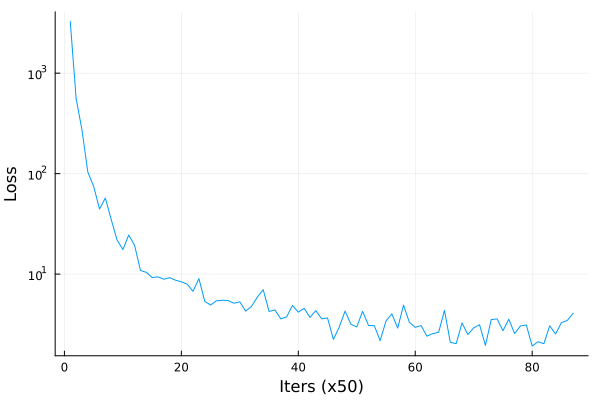

LoadError: InterruptException:

In [14]:
for iter in 1:5000000
    x = hcat([target_sample() for i in 1:batch_size]...)
    datOH = onehotbatch(x, 1:alph)

    T = rand(timesteps)
    # T = rand(timesteps)
    # T = fill(T, batch_size)
    diffusedOH = sampleforward(P, T, datOH)

    # Forward pass and loss computation
    loss, grads = Flux.withgradient(params) do
        output = model(diffusedOH, T)  # T is now directly usable
        # @show output
        # @show standardloss(P, T, output, datOH)[1]
        -standardloss(P, T, model(diffusedOH, T), datOH)[1]
    end
    
    # Update parameters
    Flux.update!(opt, params, grads)
    
    cumu_loss += loss
    if mod(iter,50) == 0
        opt[2].eta = opt[2].eta * 0.997
        push!(training_losses, cumu_loss/50)  # Changed from 100 to 50 to match the iteration count
        cumu_loss = 0.0
        IJulia.clear_output(true)
        plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x50)", label = :none) |> IJulia.display
        sleep(0.01)
    end
end
IJulia.clear_output(true)
plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x50)", label = :none)

# Evaluation

In [15]:
function zero_sample(x_t, t)
    vocab_size, seq_length, batch_size = size(x_t)
    sm = softmax(model(x_t, t))
    sampled = zeros(Bool, size(x_t))
    for b in 1:batch_size
        for s in 1:seq_length
            probs = sm[:, s, b]
            sampled_token = randcat(rng, probs)
            sampled[:, s, b] = onehotbatch([sampled_token], 1:vocab_size)
        end
    end
    return sampled
end

eq = Categorical(ones(alph)./alph)
N = 1000
seq_length = 3

# Initialize x_T with mask tokens
x_T = falses(alph, seq_length, N)
x_T[5, :, :] .= true  # Assuming 5 is the mask token index

@time samp = samplebackward(zero_sample, P, timesteps, x_T)

# Convert the result to the desired format
diff_samples = [onecold(samp[:, :, i], 1:alph) for i in 1:N];

  4.531424 seconds (3.07 M allocations: 5.465 GiB, 4.58% gc time, 11.56% compilation time)


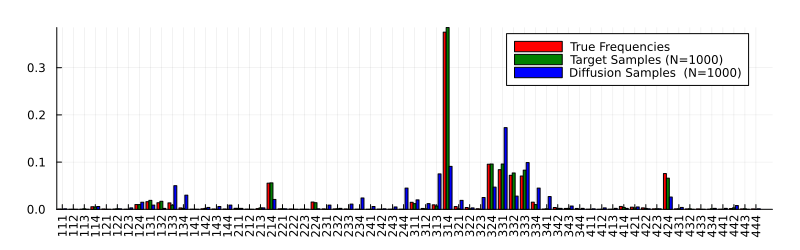

In [16]:
target_samples = [target_sample() for i in 1:N];
prop_d = proportionmap(diff_samples)
target_d = proportionmap(target_samples)
diff_freqs = [get(prop_d,a,0.0) for a in all_seqs]
target_freqs = [get(target_d,a,0.0) for a in all_seqs]

pl = groupedbar([join(string.(a)) for a in all_seqs], [all_probs target_freqs diff_freqs],
    xrotation = 90, size = (800,250), label = ["True Frequencies" "Target Samples (N=$(N))" "Diffusion Samples  (N=$(N))"],
    color = ["red" "Green" "blue"], margins = 0.5Plots.cm, xlim = (0,65))
savefig(pl,"discrete_diff_fluxIJ.pdf")
pl